# 🏠 House Prices — Advanced Regression Techniques

---
Predict **SalePrice** for Ames, Iowa homes from 79 mixed-type features (area, quality ratings, garage, neighborhood, etc.).
The focus is **RMSE / R² on a holdout split**, comparing **8 baseline regressors**, **Optuna-tuned top models**, and a **stacking ensemble** for the Kaggle submission.

## 🎯 Goals
- Explore the target distribution, missingness, and the strongest numeric predictors of price.
- Build a unified sklearn preprocessing pipeline (ordinal encoding, domain features, MI feature selection).
- Benchmark Ridge, Lasso, ElasticNet, RandomForest, SVR, XGBoost, CatBoost, and LightGBM.
- Tune the top 5 models with Optuna, then search for the best 3-model stacking combo.
- Analyze the leaderboard, plot actual vs. predicted for the best single model, and save `run_summary.json` + Kaggle submission.

> Dataset: [House Prices — Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) (`data/train.csv`, `data/test.csv` already included).

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse the existing preprocessing + modeling library under src/
SRC = Path("src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from modeling import ModelTrainer

RANDOM_STATE = 42
TARGET = "SalePrice"

DATA_DIR = Path("data")
ASSETS = Path("docs/assets"); ASSETS.mkdir(parents=True, exist_ok=True)
OUTPUTS = Path("outputs"); OUTPUTS.mkdir(parents=True, exist_ok=True)

# Full retrain takes ~60–90 min on CPU (8 baselines + Optuna + stacking).
# Set True only when you want to reproduce the entire pipeline from scratch.
RUN_FULL_PIPELINE = False

# Smoke mode: fast sanity check (~5 min) when RUN_FULL_PIPELINE=True
SMOKE_TEST = False

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## 🔹 Step 1: Load the data & EDA

1,460 labeled training rows, 79 features + `SalePrice`. The target is **right-skewed** (expensive outliers), so tree models and log-transforms often help — though this pipeline keeps the raw dollar target for interpretability.

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
print(f"SalePrice — mean=${train_df[TARGET].mean():,.0f}, median=${train_df[TARGET].median():,.0f}")
train_df[[TARGET]].describe().T

Train: (1460, 81)  |  Test: (1459, 80)
SalePrice — mean=$180,921, median=$163,000


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


Top missing columns (% of rows):
PoolQC          99.5 %
MiscFeature     96.3 %
Alley           93.8 %
Fence           80.8 %
MasVnrType      59.7 %
FireplaceQu     47.3 %
LotFrontage     17.7 %
GarageQual       5.5 %
GarageFinish     5.5 %
GarageType       5.5 %
GarageYrBlt      5.5 %
GarageCond       5.5 %
dtype: object


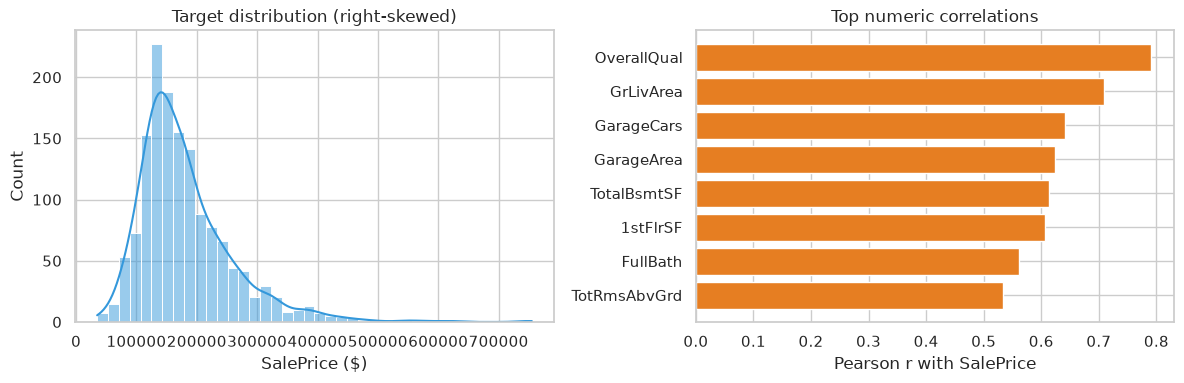

In [3]:
missing = train_df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0].head(12)
print("Top missing columns (% of rows):")
print((missing * 100).round(1).astype(str) + " %")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df[TARGET], bins=40, kde=True, ax=axes[0], color="#3498db")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_title("Target distribution (right-skewed)")

num_cols = train_df.select_dtypes(include="number").columns.drop(TARGET)
corr = train_df[num_cols].corrwith(train_df[TARGET]).sort_values(key=abs, ascending=False).head(8)
axes[1].barh(corr.index[::-1], corr.values[::-1], color="#e67e22")
axes[1].set_xlabel("Pearson r with SalePrice")
axes[1].set_title("Top numeric correlations")

fig.tight_layout()
fig.savefig(ASSETS / "target_eda.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 2: Preprocessing & train/holdout split

The shared feature pipeline (under `src/preprocessing/`) applies:
- **Ordinal encoding** for quality/condition columns (`Ex` > `Gd` > ... > `Po`)
- **Domain features** (total area, house age, bathroom counts, etc.)
- **Variance filter** + **mutual-information top-200 feature selection**

The holdout split uses **stratified quantile binning on SalePrice** so expensive and cheap homes are represented in both sets.

In [4]:
trainer = ModelTrainer(
    target_col=TARGET,
    test_size=0.2,
    random_state=RANDOM_STATE,
    output_dir=str(OUTPUTS),
)

trainer.load_data(str(DATA_DIR / "train.csv"))
trainer.split_data()
trainer.build_preprocessing()

print(f"Train features: {trainer.X_train_.shape}  |  Holdout: {trainer.X_test_.shape}")
print(f"Preprocessor steps: {[s[0] for s in trainer.feature_pipe_.steps]}")

2026-07-09 17:26:38 - INFO - Loading data from data/train.csv


2026-07-09 17:26:38 - INFO - Data loaded with shape (1460, 81)


2026-07-09 17:26:38 - INFO - Using stratified split with 15 quantile bins for target.


2026-07-09 17:26:38 - INFO - Train shape: (1168, 80), Test shape: (292, 80)


2026-07-09 17:26:38 - INFO - Feature preprocessing pipeline built successfully.


Train features: (1168, 80)  |  Holdout: (292, 80)
Preprocessor steps: ['domain', 'ordinal_map', 'missing_indicator', 'rare_grouper', 'outlier_clip', 'col_transform', 'finite_clean', 'drop_all_nan', 'var_selector', 'mi_selector']


## 🔹 Step 3: Model selection — baselines → Optuna tuning → stacking

| Stage | What happens |
|---|---|
| **Baselines** | 8 regressors trained with 5-fold CV + holdout evaluation |
| **Optuna tuning** | Top 5 models by CV-RMSE get 30 trials each (+ GridSearch for Ridge) |
| **Stacking** | Optuna searches over 3-model combos from the tuned pool (40 trials) |

By default this notebook **loads the saved results** from a prior full run (`outputs/model_results.csv`).
Set `RUN_FULL_PIPELINE = True` at the top to retrain everything (~60–90 min CPU).

In [5]:
results_path = OUTPUTS / "model_results.csv"

if RUN_FULL_PIPELINE:
    top_k = 2 if SMOKE_TEST else 5
    trials_model = 2 if SMOKE_TEST else 30
    trials_stack = 2 if SMOKE_TEST else 40
    cv_splits = 2 if SMOKE_TEST else 5

    trainer.run_full_model_selection_and_stacking(
        top_k=top_k,
        n_trials_model=trials_model,
        n_trials_stack=trials_stack,
        cv_splits=cv_splits,
    )
    print(f"Pipeline finished — {len(trainer.results_)} models evaluated")
else:
    if not results_path.exists():
        raise FileNotFoundError(
            f"{results_path} not found. Set RUN_FULL_PIPELINE=True to train from scratch."
        )
    results_df = pd.read_csv(results_path, index_col=0)
    trainer.results_ = results_df.to_dict(orient="index")
    print(f"Loaded existing results from {results_path} ({len(trainer.results_)} models)")

leaderboard = (
    pd.DataFrame(trainer.results_).T
    .sort_values("test_rmse")
    .reset_index()
    .rename(columns={"index": "model"})
)
leaderboard[["model", "test_rmse", "test_r2", "cv_rmse_mean"]].round(2)

Loaded existing results from outputs/model_results.csv (14 models)


,model,test_rmse,test_r2,cv_rmse_mean
0,xgb,26357.23,0.90,28267.44
1,xgb_tuned,26357.23,0.90,28267.44
2,catboost,28497.36,0.89,25948.06
3,catboost_tuned,28659.27,0.89,25863.82
4,stacking_optuna,29336.61,0.88,25608.74
5,random_forest_tuned,31988.50,0.86,28085.78
6,random_forest,32021.02,0.86,28088.46
7,lgbm,32435.31,0.86,33245.52
8,ridge,34010.88,0.84,28519.48
9,elasticnet,34548.90,0.84,27747.44


## 🔹 Step 4: Analyze the leaderboard

**Key finding:** the best *single* holdout model is **XGBoost** (RMSE ≈ 26.4k, R² ≈ 0.905), beating the stacking ensemble on the holdout split (RMSE ≈ 29.3k). Stacking still wins on **CV-RMSE** (25.6k) and is what we submit to Kaggle — ensembles often generalize better on unseen test data even when holdout RMSE is slightly worse.

Tree boosters (XGBoost, CatBoost) dominate linear models here because the feature space mixes ordinals, categoricals, and non-linear interactions (quality × area × neighborhood).

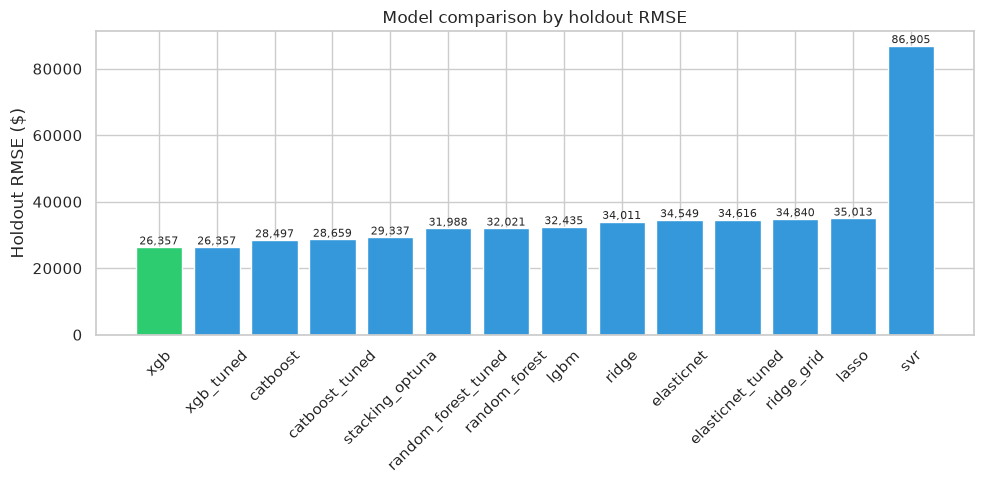

Best single model: xgb  RMSE=26,357  R²=0.905
Stacking ensemble: RMSE=29,337  (used for Kaggle submission)


In [6]:
best_single = leaderboard.iloc[0]["model"]
best_rmse = leaderboard.iloc[0]["test_rmse"]
best_r2 = leaderboard.iloc[0]["test_r2"]
stack_row = leaderboard[leaderboard["model"] == "stacking_optuna"]
stack_rmse = float(stack_row["test_rmse"].iloc[0]) if len(stack_row) else None

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = leaderboard.sort_values("test_rmse")
colors = ["#2ecc71" if m == best_single else "#3498db" for m in plot_df["model"]]
bars = ax.bar(plot_df["model"], plot_df["test_rmse"], color=colors)
ax.set_ylabel("Holdout RMSE ($)")
ax.set_title("Model comparison by holdout RMSE")
ax.tick_params(axis="x", rotation=45)
for b, v in zip(bars, plot_df["test_rmse"]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(ASSETS / "rmse_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Best single model: {best_single}  RMSE={best_rmse:,.0f}  R²={best_r2:.3f}")
if stack_rmse is not None:
    print(f"Stacking ensemble: RMSE={stack_rmse:,.0f}  (used for Kaggle submission)")

2026-07-09 17:26:38 - INFO - Training and cross validating model 'xgb'


Fitting 'xgb' for actual-vs-predicted plot...


2026-07-09 17:26:43 - INFO - [xgb] CV RMSE=28888.2271±5876.5578 CV R2=0.8592±0.0496


2026-07-09 17:26:47 - INFO - [xgb] Test RMSE=26357.2332 Test R2=0.9047


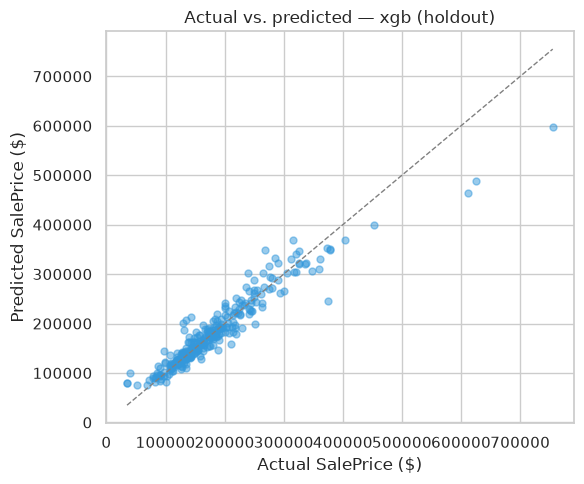

In [7]:
# Actual vs. predicted for the best single model on the holdout split.
# If the full pipeline wasn't re-run, fit XGBoost only (~2–5 min) for this diagnostic plot.
plot_model = "xgb" if "xgb" in trainer.get_default_models(RANDOM_STATE) else best_single

if plot_model not in trainer.models_:
    print(f"Fitting '{plot_model}' for actual-vs-predicted plot...")
    trainer.train_single_model(
        plot_model,
        trainer.get_default_models(RANDOM_STATE)[plot_model],
        cv_splits=3,
    )

pipe = trainer.models_[plot_model]
y_pred = pipe.predict(trainer.X_test_)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(trainer.y_test_, y_pred, alpha=0.5, s=25, color="#3498db")
lims = [min(trainer.y_test_.min(), y_pred.min()), max(trainer.y_test_.max(), y_pred.max())]
ax.plot(lims, lims, "--", color="gray", lw=1)
ax.set_xlabel("Actual SalePrice ($)")
ax.set_ylabel("Predicted SalePrice ($)")
ax.set_title(f"Actual vs. predicted — {plot_model} (holdout)")
fig.tight_layout()
fig.savefig(ASSETS / "actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 5: Kaggle submission & save artifacts

The stacking ensemble is saved and used for the Kaggle test set (1,459 rows). If you ran the full pipeline, the fitted model is already in memory; otherwise we load the saved `.joblib` if present.

In [8]:
submission_model = "stacking_optuna"
model_path = OUTPUTS / f"{submission_model}.joblib"

if submission_model not in trainer.models_:
    if model_path.exists():
        trainer.load_model(str(model_path), name=submission_model)
        print(f"Loaded saved model: {model_path}")
    elif RUN_FULL_PIPELINE:
        trainer.save_model(submission_model)
    else:
        print(f"No saved {submission_model} model — skipping submission (re-run with RUN_FULL_PIPELINE=True)")

if submission_model in trainer.models_:
    submission_path = trainer.make_submission(
        test_data_path=str(DATA_DIR / "test.csv"),
        submission_path=str(OUTPUTS / f"submission_{submission_model}.csv"),
        model_name=submission_model,
    )
    print(f"Saved submission: {submission_path}")
else:
    submission_path = OUTPUTS / f"submission_{submission_model}.csv"
    if submission_path.exists():
        print(f"Using existing submission: {submission_path}")
    else:
        submission_path = None

No saved stacking_optuna model — skipping submission (re-run with RUN_FULL_PIPELINE=True)
Using existing submission: outputs/submission_stacking_optuna.csv


In [9]:
summary = {
    "best_single_model": best_single,
    "best_single_test_rmse": float(best_rmse),
    "best_single_test_r2": float(best_r2),
    "stacking_test_rmse": stack_rmse,
    "stacking_cv_rmse": float(stack_row["cv_rmse_mean"].iloc[0]) if len(stack_row) else None,
    "n_models_evaluated": int(len(leaderboard)),
    "n_train": int(len(trainer.X_train_)),
    "n_holdout": int(len(trainer.X_test_)),
    "submission_model": submission_model,
    "submission_path": str(submission_path.resolve()) if submission_path and Path(submission_path).exists() else None,
    "leaderboard_top5": leaderboard.head(5)[["model", "test_rmse", "test_r2"]].round(2).to_dict(orient="records"),
}
with open(ASSETS / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved: docs/assets/run_summary.json, docs/assets/rmse_comparison.png, docs/assets/actual_vs_predicted.png")
print(json.dumps({k: summary[k] for k in ["best_single_model", "best_single_test_rmse", "stacking_test_rmse"]}, indent=2))

Saved: docs/assets/run_summary.json, docs/assets/rmse_comparison.png, docs/assets/actual_vs_predicted.png
{
  "best_single_model": "xgb",
  "best_single_test_rmse": 26357.23323871457,
  "stacking_test_rmse": 29336.613279824403
}


## ✅ Conclusion

- **OverallQual**, **GrLivArea**, and **GarageCars** are among the strongest numeric predictors — house quality and living space dominate price, as expected in a midwestern housing market.
- **XGBoost wins on the holdout split** (RMSE ≈ $26.4k, R² ≈ 0.905), narrowly beating CatBoost and the tuned variants. Linear models (Ridge/Lasso/ElasticNet) land in the $34–35k RMSE range — the feature interactions are too non-linear for L2/L1 alone.
- **SVR collapses** (RMSE ≈ $87k, R² ≈ 0) — RBF-SVR doesn't scale to ~200 high-dimensional mixed features without heavy tuning.
- **Stacking vs. single model trade-off:** stacking achieves the best **CV-RMSE** (≈ $25.6k) and is used for the Kaggle submission, but its holdout RMSE (≈ $29.3k) is slightly worse than XGBoost alone. This is normal — CV-optimized ensembles don't always win on a single random split.
- **Preprocessing matters:** ordinal encoding + domain features + MI feature selection compress 79 raw columns into ~200 informative features that all models share via a single `Pipeline`.

**Possible next steps:** log-transform `SalePrice` as the target, try a pure CatBoost pipeline with native categorical handling, or add spatial/neighborhood clustering features from `Neighborhood`.